# 4. Building an Assistant

Sub-goals, controlability, external tools, and parallelisation

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
| 26/05/26   | Martin | CREATE   | Notebook for Module 4 of Langgraph tutorial. Parallelisation | 
| 28/05/26   | Martin | UPDATE   | Sub-graphs and Map-reduce | 
| 04/06/26   | Martin | UPDATE   | Started on research agent | 
| 05/06/26   | Martin | UPDATE   | Continued with research agents: questions loop done | 
| 07/06/26   | Martin | UPDATE   | Completed research agent graph. Completed Module 4 |

# Content

* [Parallelisation](#parallelisation)
* [Sub-Graphs](#sub-graphs)
* [Map-Reduce](#map-reduce)
* [Research Assistant](#research-assistant)

# Parallelisation

Running multiple nodes that update the state at the same time. _Fan-in-fan-out_ is one of the ways a graph can be contructed to run in parallel i.e at least 2 nodes running at the same time.

__BUT__ because the state is always overridden, a __reducer__ is required to run parallel nodes

- All steps within a parallel path will wait for each other to complete before proceeding on to the next step

In [ ]:
import os
import operator
from dotenv import load_dotenv

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch

from IPython.display import Image, display

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

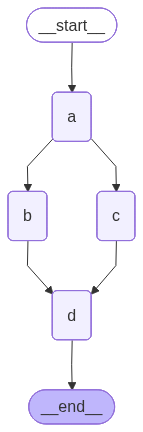

In [5]:
class State(TypedDict):
    state: Annotated[list, operator.add]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State):
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A."))
builder.add_node("b", ReturnNodeValue("I'm B."))
builder.add_node("c", ReturnNodeValue("I'm C."))
builder.add_node("d", ReturnNodeValue("I'm D."))

builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

__🧑‍🏫 LESSON:__ Here because nodes "b" and "c" need to simultaneously update the state (which by default will override) we use the `operator.add` with a custom State to ensure values get appended

In [4]:
graph.invoke({"state": []})

Adding I'm A. to []
Adding I'm B. to ["I'm A."]
Adding I'm C. to ["I'm A."]
Adding I'm D. to ["I'm A.", "I'm B.", "I'm C."]


{'state': ["I'm A.", "I'm B.", "I'm C.", "I'm D."]}

## Setting the order of state updates

Use a __custom reducer__ to customise the order of nodes which are run within the parallised loop.

🥬 e.g. Below shows a reducer that runs the nodes based on their sorted name order

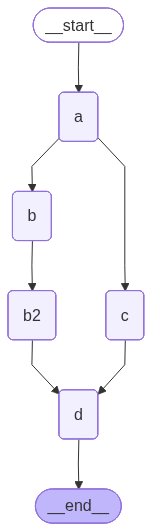

In [10]:
def sorting_reducer(left: list, right: list) -> list:
    """ Combines and sorts the values in a list"""
    return sorted(left + right, reverse=False)

class State(TypedDict):
    # sorting_reducer will sort the values in state
    state: Annotated[list, sorting_reducer]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State):
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}


# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm B2", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm B2", "I'm C", "I'm D"]}

## Working with LLMs

Combining a parallel routing with LLMs

In [13]:
class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

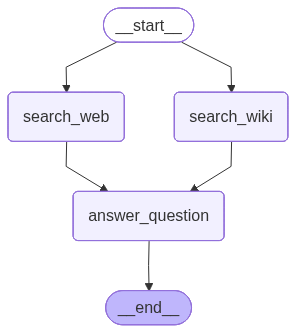

In [14]:
def search_web(state):
    """Retrieve docs from web search"""
    # Search
    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": state['question']})
    search_docs = data.get("results", data)

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

def search_wikipedia(state):
    """Retreive documents from wikipedia"""
    search_docs = WikipediaLoader(query=state['question'], load_max_docs=2).load()

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

def generate_answer(state):
    """Node to answer questions"""
    # Get state
    question = state['question']
    context = state['context']

    # Format
    query = f"Answer the question {question} using this context: {context}"

    # Answer
    answer = llm.invoke(
        [SystemMessage(content=query)],
        [HumanMessage(content="Answer the question.")]
    )

    return {"answer": answer}

builder = StateGraph(State)
builder.add_node("search_web", search_web)
builder.add_node("search_wiki", search_wikipedia)
builder.add_node("answer_question", generate_answer)

builder.add_edge(START, "search_wiki")
builder.add_edge(START, "search_web")
builder.add_edge("search_wiki", "answer_question")
builder.add_edge("search_web", "answer_question")
builder.add_edge("answer_question", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke({"question": "How were Nvidia's Q2 2025 earnings"})
result['answer'].content

---

# Sub-graphs

Sub-graphs allow you to create and manage different states in different parts of the graph.

Communication between graphs is done via __overlapping keys__

- Sub-graphs can access key from the parent graph if they are the same

🥬 e.g. Logs with different tasks

- System accepts logs
- 1 task summarises the logs, 1 task finds failure nodes
- Perform both operations in different subgraphs

![subgraphs](./assets/subgraph.png)

In [ ]:
from operator import add
from typing import TypedDict, List, Optional, Annotated

from langgraph.graph import StateGraph
from langgraph.constants import START, END

In [16]:
# Define the entire log structure
class Log(TypedDict):
    id: str
    question: str
    docs: Optional[List]
    answer: str
    grade: Optional[int]
    grader: Optional[str]
    feedback: Optional[str]

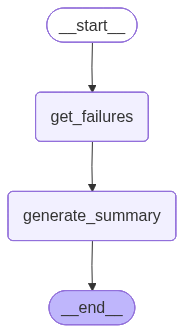

In [17]:
# Failure analysis sub-graph
class FailureAnalysisState(TypedDict):
    cleaned_logs: List[Log]
    failures: List[Log]
    fa_summary: str
    processed_logs: List[str]

# Define a separate output state, so that when the subgraph returns results back to
# main graph, there won't be a collision in the results returned
class FailureAnalysisOutputState(TypedDict):
    fa_summary: str
    processed_logs: List[str]

def get_failures(state):
    """Get logs that contain failures"""
    failures = [log for log in state['cleaned_logs'] if "grade" in log]
    return {"failures": failures}

def generate_summary(state):
    """Generate a summary of the failures"""
    failures = state['failures']
    fa_summary = "Poor quality retrieval of Chroma documentation."
    return {
        "fa_summary": fa_summary,
        "processed_logs": [
            f"failure-analysis-on-log-{failure['id']}" for failure in failures
        ]
    }

fa_builder = StateGraph(
    state_schema=FailureAnalysisState,
    output_schema=FailureAnalysisOutputState
)
fa_builder.add_node("get_failures", get_failures)
fa_builder.add_node("generate_summary", generate_summary)

fa_builder.add_edge(START, "get_failures")
fa_builder.add_edge("get_failures", "generate_summary")
fa_builder.add_edge("generate_summary", END)

graph = fa_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

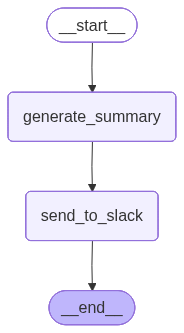

In [18]:
# Summarisation sub-graph
class QuestionSummarisationState(TypedDict):
    cleaned_logs: List[Log]
    qs_summary: str
    report: str
    processed_logs: List[str]

class QuestionSummarisationOutputState(TypedDict):
    report: str
    processed_logs: List[str]

def generate_summary(state):
    cleaned_logs = state["cleaned_logs"]
    summary = "Questions focused on usage of ChatOllama and Chroma vector store."
    return {
        "qs_summary": summary,
        "processed_logs": [f"summary-on-log-{log['id']}" for log in cleaned_logs]
    }

def send_to_slack(state):
    qs_summary = state['qs_summary']
    report = f"Some report generated from the summary: {qs_summary}"
    return {"report": report}

qs_builder = StateGraph(
    state_schema=QuestionSummarisationState,
    output_schema=QuestionSummarisationOutputState
)
qs_builder.add_node("generate_summary", generate_summary)
qs_builder.add_node("send_to_slack", send_to_slack)

qs_builder.add_edge(START, "generate_summary")
qs_builder.add_edge("generate_summary", "send_to_slack")
qs_builder.add_edge("send_to_slack", END)

graph = qs_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

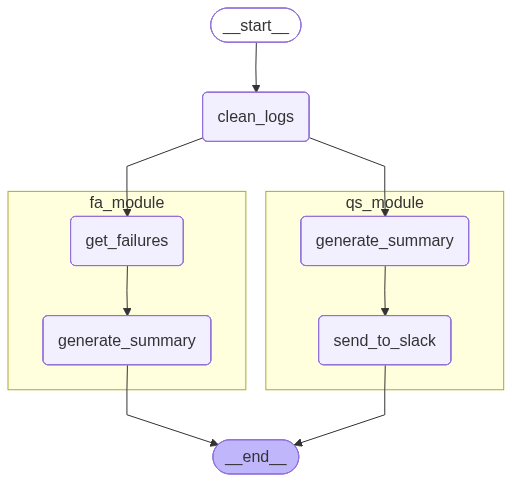

In [21]:
# Entry graph - Main graph loop
class EntryGraphState(TypedDict):
    raw_logs: List[Log]
    cleaned_logs: List[Log]
    fa_summary: str                            # Used only by FA sub-graph
    report: str                                # Used only by QS sub-graph
    processed_logs: Annotated[List[int], add]  # Used and updated by both graphs

def clean_logs(state):
    raw_logs = state["raw_logs"]
    cleaned_logs = raw_logs  # Some cleaning can be done here
    return {"cleaned_logs": raw_logs}

entry_builder = StateGraph(EntryGraphState)
entry_builder.add_node("clean_logs", clean_logs)
entry_builder.add_node("qs_module", qs_builder.compile())
entry_builder.add_node("fa_module", fa_builder.compile())

entry_builder.add_edge(START, "clean_logs")
entry_builder.add_edge("clean_logs", "qs_module")
entry_builder.add_edge("clean_logs", "fa_module")
entry_builder.add_edge("fa_module", END)
entry_builder.add_edge("qs_module", END)

graph = entry_builder.compile()
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [22]:
question_answer = Log(
    id="1",
    question="How can I import ChatOllama?",
    answer="To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'",
)

question_answer_feedback = Log(
    id="2",
    question="How can I use Chroma vector store?",
    answer="To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).",
    grade=0,
    grader="Document Relevance Recall",
    feedback="The retrieved documents discuss vector stores in general, but not Chroma specifically",
)

raw_logs = [question_answer,question_answer_feedback]
graph.invoke({"raw_logs": raw_logs})

{'raw_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, but not Chroma specifically'}],
 'cleaned_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, 

---

# Map-Reduce

The map-reduce paradigm allows us to spawn any number of replicated nodes to perform tasks in parallel for different instances, then combine them back into a single output.

🥬 e.g. Build a joke creator based on a topic and selects the best one

In [1]:
import os
import operator
from dotenv import load_dotenv
from pydantic import BaseModel

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from langgraph.types import Send
from langchain_groq import ChatGroq

from IPython.display import Image

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

In [2]:
subject_prompt = "Create a list of 3 sub-topics that are related to the overall " \
    "topic: {topic}."
joke_prompt = "Generate a joke about: {subject}"
best_joke_prompt = "Based on the jokes below on {topic}. Select the best one, and" \
    "return the ID of the selected, starting 0 as the ID for the first joke. Jokes: " \
    "\n\n {jokes}"

In [3]:
# Define the States
class Subject(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int

class OverallState(TypedDict):
    topic: str
    subjects: list[str]
    jokes: Annotated[list[str], operator.add]
    best_selected_joke: str

In [4]:
def generate_topics(state: OverallState):
    """Generate a set of subjects based on the topic given"""
    prompt = subject_prompt.format(topic=state['topic'])
    subjects = llm.with_structured_output(Subject).invoke(prompt)
    return {"subjects": subjects.subjects}

def continue_to_jokes(state: OverallState):
    """For every subject created, send it to a node to create a joke"""
    return [Send("generate_joke", {"subject": s}) for s in state['subjects']]

In [5]:
class JokeState(BaseModel):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    """Generate a joke based on the topic"""
    prompt = joke_prompt.format(subject=state['subject'])
    joke = llm.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [joke.joke]}

In [6]:
def get_best_joke(state: OverallState):
    jokes = "\n\n".join(state['jokes'])
    prompt = best_joke_prompt.format(
        topic=state['topic'],
        jokes=jokes
    )
    best = llm.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state['jokes'][best.id]}

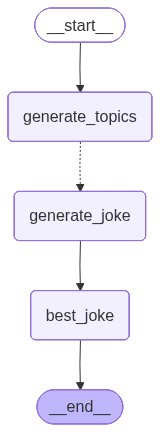

In [7]:
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", get_best_joke)

graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)

app = graph.compile()
Image(app.get_graph().draw_mermaid_png())

In [8]:
for s in app.stream({"topic": "board games"}):
    print(s)

{'generate_topics': {'subjects': ['Types of Board Games', 'Board Game Mechanics', 'History of Board Games']}}
{'generate_joke': {'jokes': ['Why did the board game pieces go to therapy? Because they were feeling a little boxed in!']}}
{'generate_joke': {'jokes': ['Why did the board game go to therapy? It had a lot of history to work through!']}}
{'generate_joke': {'jokes': ['Why did the game designer break up with his girlfriend? He needed space, but she was always rolling a 7.']}}
{'best_joke': {'best_selected_joke': 'Why did the board game pieces go to therapy? Because they were feeling a little boxed in!'}}


---

# Research Assistant

Multi-agent research automation system. Raw LLM outputs are poorly suited for real-world workflows or challenging decisions. 

🎯 GOAL: Build a lightweight, multi-agent system around LLMs that optimises and customises the research process

<u>Process</u>

1. __Source Selection__: User chooses any set of input sources for the research
2. __Planning__: Based on a chosen topic, spin up multiple agents each focusing on a sub-topic. Human-in-the-loop to refine sub-topics before research begins
3. __LLM Utilisation__: "Analyst" (Agent) will continually ask questions and answer them and produce the research output
4. __Research Process__: Experts will gather information in parallel and map-reduce will compile them together
5. __Output Format__: Gathered insights will be synthesized into a final report. Custom report structure

In [23]:
import os
import operator

from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from IPython.display import Image, display, Markdown

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.constants import START, END
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_community.document_loaders import WikipediaLoader
from langchain_core.messages import get_buffer_string
from langgraph.types import Send

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

In [2]:
# Define states
class Analyst(BaseModel):
    affiliation: str = Field(description="Primary affilisation of the analyst")
    name: str = Field(description="Name of the analyst")
    role: str = Field(description="Role of the analyst in the context of the topic")
    description: str = Field(
        description="Description of the analyst focus, concerns and motives"
    )

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\n Affiliation: {self.affiliation}" \
               f"\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="List of analysts with roles and affiliations"
    )

class GenerateAnalystsState(TypedDict):
    topic: str                  # Research topic
    max_analysts: int           # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst]     # Analysts asking questions

In [3]:
analyst_instructions = """You are tasked with creating a set of AI analyst personas.
Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of
the analysts:

{human_analyst_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes?

5. Assign one analyst to each theme?"""

def create_analysts(state: GenerateAnalystsState):
    """Create Analysts"""
    topic = state['topic']
    max_analysts = state['max_analysts']
    human_analyst_feedback = state.get('human_analyst_feedback', '')

    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    system_message = analyst_instructions.format(
        topic=topic,
        human_analyst_feedback=human_analyst_feedback,
        max_analysts=max_analysts
    )

    # Invoke the LLM
    analysts = structured_llm.invoke(
        [SystemMessage(content=system_message)] +
        [HumanMessage(content="Generate a set of analysts")]
    )

    return {"analysts": analysts.analysts}


def human_feedback(state: GenerateAnalystsState):
    """Np-op node that should be interrupted on"""
    pass


def should_continue(state: GenerateAnalystsState):
    human_analyst_feedback = state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"

    return END

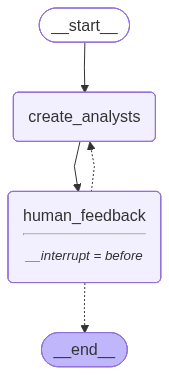

In [4]:
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)

builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges(
    "human_feedback",
    should_continue,
    ["create_analysts", END]
)

memory = MemorySaver()
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=['human_feedback']
)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [5]:
topic = "Tell me more about who and when should you take protein powder"
max_analysts = 3
thread = {"configurable": {"thread_id": "15"}}

for event in graph.stream({
    "topic": topic,
    "max_analysts": max_analysts,
}, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}") 
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Fitness Enthusiast
Affiliation: Gym Rat
Role: Fitness Coach
Description: Focuses on workout routines and fitness regimens, with a keen interest in muscle growth and recovery
--------------------------------------------------
Name: Nutrition Expert
Affiliation: Registered Dietitian
Role: Nutritionist
Description: Specializes in dietary plans and meal prep, with expertise in macronutrient balancing and weight management
--------------------------------------------------
Name: Health Skeptic
Affiliation: Science Journalist
Role: Science Writer
Description: Approaches health and wellness with a critical eye, questioning the efficacy of supplements and the influence of marketing
--------------------------------------------------


In [6]:
# Look at the next state node
state = graph.get_state(thread)
state.next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


('human_feedback',)

In [7]:
# Update the state
graph.update_state(
    thread,
    {
        "human_analyst_feedback": "Add in someone who has never been to the gym before"
    },
    as_node="human_feedback"
)

# Then continue running the graph
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}") 
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Fitness Enthusiast
Affiliation: Gym Rat
Role: Fitness Coach
Description: Focuses on workout routines and fitness regimens, with a keen interest in muscle growth and recovery
--------------------------------------------------
Name: Nutrition Expert
Affiliation: Registered Dietitian
Role: Nutritionist
Description: Specializes in dietary plans and meal prep, with expertise in macronutrient balancing and weight management
--------------------------------------------------
Name: Health Skeptic
Affiliation: Science Journalist
Role: Science Writer
Description: Approaches health and wellness with a critical eye, questioning the efficacy of supplements and the influence of marketing
--------------------------------------------------


Name: Fitness Expert
Affiliation: Gym
Role: Fitness coach
Description: Provides guidance on workout routines, diet plans, and supplements for achieving fitness goals
--------------------------------------------------
Name: Nutritionist
Affiliation: Health clinic
Role: Dietary advisor
Description: Specializes in creating personalized meal plans and provides advice on healthy eating habits
--------------------------------------------------
Name: Bodybuilder
Affiliation: Bodybuilding community
Role: Athlete
Description: Competes at the professional level and shares knowledge on effective workout regimens and supplement stacks
--------------------------------------------------
Name: Gym Newbie
Affiliation: Local gym
Role: Beginner
Description: Just starting their fitness journey and provides a fresh perspective on the challenges and benefits of working out
--------------------------------------------------
Name: Sports Scientist
Affiliation: University
Role: Researcher
Description: Conduct

In [8]:
# Ending the loop
further_feedback = None
graph.update_state(
    thread,
    {
        "human_analyst_feedback": further_feedback,
    },
    as_node="human_feedback"
)

for event in graph.stream(None, thread, stream_mode="updates"):
    print("---- Node ----")
    node = next(iter(event.keys()))
    print(node)

final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')
print(final_state.next)

()


In [9]:
# List final set of analysts
for analyst in analysts:
    print(f"Name: {analyst.name}") 
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50)

Name: Fitness Expert
Affiliation: Gym
Role: Fitness coach
Description: Provides guidance on workout routines, diet plans, and supplements for achieving fitness goals
--------------------------------------------------
Name: Nutritionist
Affiliation: Health clinic
Role: Dietary advisor
Description: Specializes in creating personalized meal plans and provides advice on healthy eating habits
--------------------------------------------------
Name: Bodybuilder
Affiliation: Bodybuilding community
Role: Athlete
Description: Competes at the professional level and shares knowledge on effective workout regimens and supplement stacks
--------------------------------------------------
Name: Gym Newbie
Affiliation: Local gym
Role: Beginner
Description: Just starting their fitness journey and provides a fresh perspective on the challenges and benefits of working out
--------------------------------------------------
Name: Sports Scientist
Affiliation: University
Role: Researcher
Description: Conduct

## Conducting the interviews

Each agent (for each topic) will now ask questions to an "expert", who is a source of information on the specific topic.

In [10]:
class InterviewState(MessagesState):
    max_num_turns: int                      # Number of conversation rounds
    context: Annotated[list, operator.add]  # Source docs
    analyst: Analyst                        # Analyst to be asking the questions
    interview: str                          # Interview transcript
    sections: list                          # Final key douplicated in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval")

In [11]:
question_instructions = """You are an analyst tasked with interviewing an expert to
 learn about a specific topic. Your goal is boil down to interesting and
 specific insights related to your topic.
    1. Interesting: Insights that people will find surprising or non-obvious.
    2. Specific: Insights that avoid generalities and include specific examples from
the expert.

 Here is your topic of focus and set of goals: {goals}

 Begin by introducing yourself using a name that fits your persona, and then ask your
 question. Continue to ask questions to drill down and refine your understanding of the
 topic. When you are satisfied with your understanding, complete the interview with:
 "Thank you so much for your help!" Remember to stay in character throughout your
 response, reflecting the persona and goals provided to you."""


def generate_questions(state: InterviewState):
    """Node to generate a question"""
    analyst = state['analyst']
    messages = state['messages']

    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(system_message)] + messages)
    return {"messages": [question]}

## Generate answers

Expert here will gather information from wikipedia to answer questions

<u>Other Tool Options</u>

- Specific websites via `WebBaseLoader`
- Indexed documents via RAGs
- Web Search tool

Create node to search wikipedia and return documents found

In [12]:
search_instructions = """You will be given a conversation between an analyst and an
 expert. Your goal is to generate a well-structured query for use in retrieval and / or
 web-search related to the conversation. First, analyze the full conversation.
 Pay particular attention to the final question posed by the analyst.
 Convert this final question into a well-structured web search query"""

def search_wiki(state: InterviewState):
    """Node to find wikipedia documents for the given conversation"""
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke(
        [SystemMessage(content=search_instructions)] +
        state['messages']
    )

    search_docs = WikipediaLoader(
        query=search_query.search_query,
        load_max_docs=2
    ).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="'
            f'{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

Now have the expert return the answer based on it's role, topic and the found context

In [13]:
answer_instructions = """You are an expert being interviewed by an analyst. Here is
 analyst area of focus: {goals}. You goal is to answer a question posed by the
 interviewer. To answer question, use this context:

 {context}

 When answering questions, follow these guidelines:
    1. Use only the information provided in the context.
    2. Do not introduce external information or make assumptions beyond what is
     explicitly stated in the context.
    3. The context contain sources at the topic of each individual document.
    4. Include these sources your answer next to any relevant statements. For example,
     for source # 1 use [1].
    5. List your sources in order at the bottom of your answer. [1] Source 1, [2]
     Source 2, etc
    6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>'
     then just list:
     [1] assistant/docs/llama3_1.pdf, page 7 
     And skip the addition of the brackets as well as the Document source preamble in
     your citation."
"""

def generate_answer(state: InterviewState):
    """Node to answer questions"""
    analyst = state['analyst']
    messages = state['messages']
    context = state['context']

    system_message = answer_instructions.format(
        goals=analyst.persona,
        context=context
    )
    answer = llm.invoke([SystemMessage(content=system_message)] + messages)

    answer.name = "expert"

    return {"messages": [answer]}


def save_interview(state: InterviewState):
   """Save interviews"""
   messages = state['messages']
   interview = get_buffer_string(messages)

   return {"interview": interview}


Next, define the logic used to route messages

In [14]:
def route_messages(state: InterviewState, name: str = "expert"):
    """Route between question and answer"""
    messages = state['messages']
    max_num_turns = state.get("max_num_turns", 2)

    # Check the number of expert answers
    num_expert_answers = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # Condition 1: Number of messages exceeds max number of rounds
    if num_expert_answers >= max_num_turns:
        return "save_interview"

    # Condition 2: Last question
    last_question = messages[-2]

    if "Thank you so much for your help" in last_question.content:
        return "save_interview"
    return "ask_question"


Write a report based on the answers

In [15]:
section_writer_instructions = """You are an expert technical writer.

Your task is to create a short, easily digestible section of a report based on a set of
 source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document
 tag.

2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers

3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst:
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the
 analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the
 interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source
 documents

6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/

8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

def write_section(state: InterviewState):
    """Node to write a section of the final report"""
    interview = state['interview']
    context = state['context']
    analyst = state['analyst']

    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke(
        [SystemMessage(content=system_message)] + \
        [HumanMessage(content=f"Use this source to write your section: {context}")]
    )

    return {"section": [section.content]}


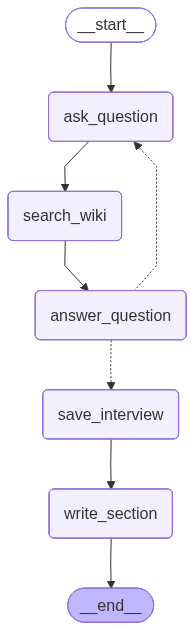

In [16]:
# Build the graph
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_questions)
interview_builder.add_node("search_wiki", search_wiki)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_wiki")
interview_builder.add_edge("search_wiki", "answer_question")
interview_builder.add_conditional_edges(
    "answer_question",
    route_messages,
    ['ask_question', 'save_interview']
)
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory) \
    .with_config(run_name="Conduct Interviews")

display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [17]:
analysts[0]

Analyst(affiliation='Gym', name='Fitness Expert', role='Fitness coach', description='Provides guidance on workout routines, diet plans, and supplements for achieving fitness goals')

In [ ]:
# Return the response for a single analyst
messages = [HumanMessage(content=f"So you siad you were writing an article on {topic}?")]
thread = {"configurable": { "thread_id": "20" }}
interview = interview_graph.invoke({
    "analyst": analysts[0],
    "messages": messages,
    "max_num_turns": 2
}, thread)
Markdown(interview['sections'][0])


## Parallelise all analysts

Compile the interview process as a sub-graph such that each analyst can be run in parallel.

Then collect all sections and compile them into a single Markdown report with an introduction and conclusion.

In [19]:
class ResearchGraphState(TypedDict):
    topic: str                                  # Topic of research
    max_analysts: int                           # Max number of analysts
    human_analysts_feedback: str                # Feedback from user for topics
    analysts: List[Analyst]                     # Analyst personas
    sections: Annotated[list, operator.add]     # Sections from the output of research
    introduction: str                           # Introduction for report
    content: str                                # Content of report
    conclusion: str                             # Conclusion for report
    final_report: str                           # Compiled final report


In [20]:
def initiate_all_interviews(state: ResearchGraphState):
    """Send all personas with questions to conduct interview sub-graphs"""
    human_analyst_feedback = state['human_analyst_feedback']
    if human_analyst_feedback:
        return "create_analysts"
    else:
        topic = state['topic']
        return [Send("conduct_interview", {
            "analyst": analyst[0],
            "messages": [
                HumanMessage(f"You said you were writing an article on {topic}?")
            ],
        }) for analyst in state['analysts']]


In [21]:
report_writer_instructions = """You are a technical writer creating a report on this
 overall topic:

{topic}

You have a team of analysts. Each analyst has done two things:

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task:

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas
 from all of the memos.
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:

1. Use markdown formatting.
2. Include no pre-amble for the report.
3. Use no sub-heading.
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example
 [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the
 `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state: ResearchGraphState):
    topic = state['topic']
    sections = state['sections']

    formatted_sections = "\n\n".join([f"{section}" for section in sections])

    system_message = report_writer_instructions.format(
        topic=topic,
        context=formatted_sections
    )
    report = llm.invoke(
        [SystemMessage(content=system_message)] + \
        [HumanMessage(content="Write a report based on the exerpt")]
    )

    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on
 {topic}

You will be given all of the sections of the report. You job is to write a crisp and
 compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

- Include no pre-amble for either section.
- Target around 100 words, crisply previewing (for introduction) or recapping
 (for conclusion) all of the sections of the report.
- Use markdown formatting.
- For your introduction, create a compelling title and use the # header for the title.
- For your introduction, use ## Introduction as the section header.
- For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # Summarize the sections into a final report
    instructions = intro_conclusion_instructions.format(
        topic=topic,
        formatted_str_sections=formatted_str_sections
    )
    intro = llm.invoke(
        [instructions] + \
        [HumanMessage(content="Write the report introduction")]
    )

    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # Summarize the sections into a final report
    instructions = intro_conclusion_instructions.format(
        topic=topic,
        formatted_str_sections=formatted_str_sections
    )
    conclusion = llm.invoke(
        [instructions] + \
        [HumanMessage(content="Write the report conclusion")]
    )

    return {"conclusion": conclusion.content}

# Compile reports sections
def finalise_report(state: ResearchGraphState):
    """Gather all sections, combine them and write the complete final report"""
    content = state['content']
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if '## Sources' in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state['introduction'] + \
    "\n\n----\n\n" + content + \
    "\n\n----\n\n" + state['conclusion']

    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}


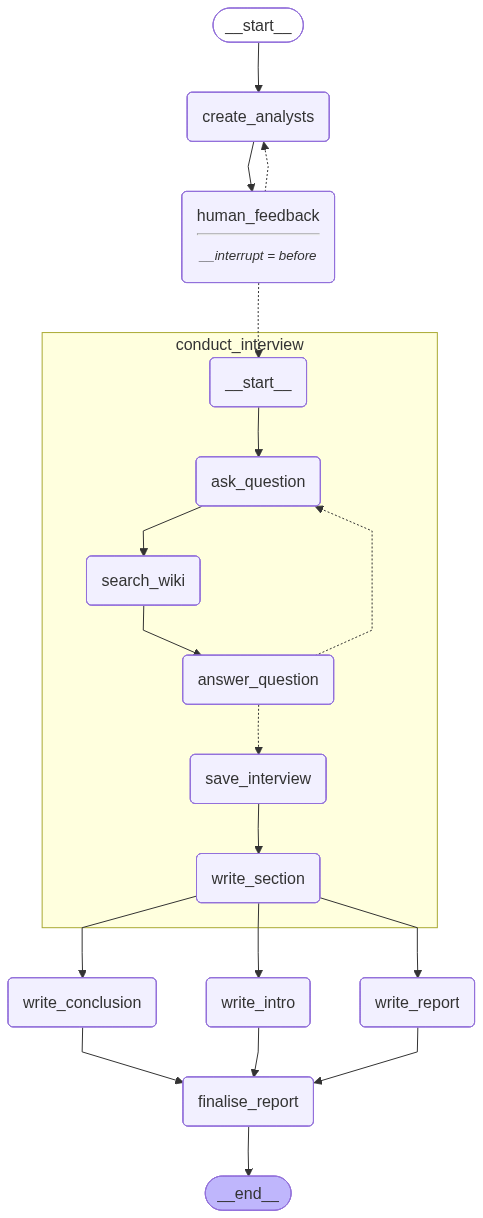

In [26]:
# Build the complete graph
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report", write_report)
builder.add_node("write_intro", write_introduction)
builder.add_node("write_conclusion", write_conclusion)
builder.add_node("finalise_report", finalise_report)

builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges(
    "human_feedback",
    initiate_all_interviews,
    ["create_analysts", "conduct_interview"]
)
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_intro")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(
    ["write_report", "write_intro", "write_conclusion"],
    "finalise_report"
)
builder.add_edge("finalise_report", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory, interrupt_before=['human_feedback'])
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
max_analysts = 3
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(
    {
        "topic":topic,
        "max_analysts":max_analysts
    },
    thread,
    stream_mode="values"
):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)


In [ ]:
# Graph pauses to update the state and await input from user
graph.update_state(
    thread,
    {
        "human_analyst_feedback": "Add in the perspective of a nutritionist"
    },
    as_node="human_feedback"
)

In [ ]:
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 


In [ ]:
graph.update_state(
    thread,
    {
        "human_analyst_feedback": None
    },
    as_node="human_feedback"
)


In [ ]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("---- Node ----")
    node_name = next(iter(event.keys()))
    print(node_name)


In [ ]:
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)


In [27]:
%load_ext watermark
%watermark

Last updated: 2026-06-07T21:42:23.705119+08:00

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.13.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 16
Architecture: 64bit

